# Five-match BSQ results

Aggregated **127 shots** across Bayern matches in the hackathon sample. Tables below load from `reference_outputs/` (full v3 S3 run).

In [1]:
from pathlib import Path
import pandas as pd
from aws_football.bsq_reports import merge_shot_tables, league_match_summary, MODULE_COLUMNS, PHASE_COLUMNS, INDEX_COLUMNS

REPO = Path('../..').resolve()
df = merge_shot_tables()
summary = league_match_summary(df)
summary

,match_folder,shots,decision_quality_score,shot_geometry_score,arrival_receiving_score,approach_prep_score,technique_mechanics_score,strike_quality_score,placement_score,strike_output_score,finishing_execution_index,P1_score,P2_score,P3_score,P4_score,P5_score,P6_score
0,Bayern_Hamburg,30,14.238597,55.076079,83.482222,69.420428,70.097174,72.694374,50.399660,71.635387,46.498789,63.736331,69.420428,72.027884,64.984115,66.165920,55.974528
1,Dortmund_Stuttgart,28,19.796941,56.995357,79.848810,62.789855,65.916554,68.623338,55.915926,67.727773,54.827454,65.432691,62.789855,68.454361,62.427149,61.040247,57.672941
2,Frankfurt_Bayern,16,20.458168,61.788714,82.169792,71.838880,73.374938,66.786536,46.842669,72.808113,46.124972,69.235161,71.838880,73.395989,62.668434,56.454233,54.280256
3,Frankfurt_Union,30,18.978903,58.669092,79.375000,62.898950,71.634588,72.469578,50.928391,72.151458,47.062087,65.898439,62.898950,67.032625,59.831923,61.182759,58.404521
4,Union_Bayern,23,23.629413,51.903138,81.300000,69.941750,65.368186,64.125268,47.170587,65.136111,48.827595,63.672537,69.941750,66.596044,59.145968,60.755790,53.365112


In [2]:
module_cols = [c for c in MODULE_COLUMNS.values() if c in df.columns]
index_cols = [c for c in INDEX_COLUMNS.values() if c in df.columns]
df[[*module_cols, *index_cols]].describe().round(1)

,decision_quality_score,shot_geometry_score,arrival_receiving_score,approach_prep_score,technique_mechanics_score,strike_quality_score,placement_score,strike_output_score,finishing_execution_index
count,125.0,127.0,127.0,127.0,97.0,89.0,127.0,127.0,126.0
mean,19.1,56.6,81.2,66.8,68.9,69.3,50.7,69.9,48.9
std,16.8,12.7,12.8,16.0,12.8,15.1,22.7,20.6,22.1
min,9.6,34.3,41.6,0.0,19.8,23.6,0.0,9.3,0.8
25%,13.1,48.7,74.5,57.7,63.5,60.1,31.8,57.8,32.7
50%,14.6,54.3,84.1,67.9,71.6,72.1,52.9,74.8,50.2
75%,16.1,63.4,90.5,76.8,78.3,80.0,65.1,85.8,65.2
max,99.2,96.6,98.1,100.0,88.2,95.7,96.6,96.8,97.9


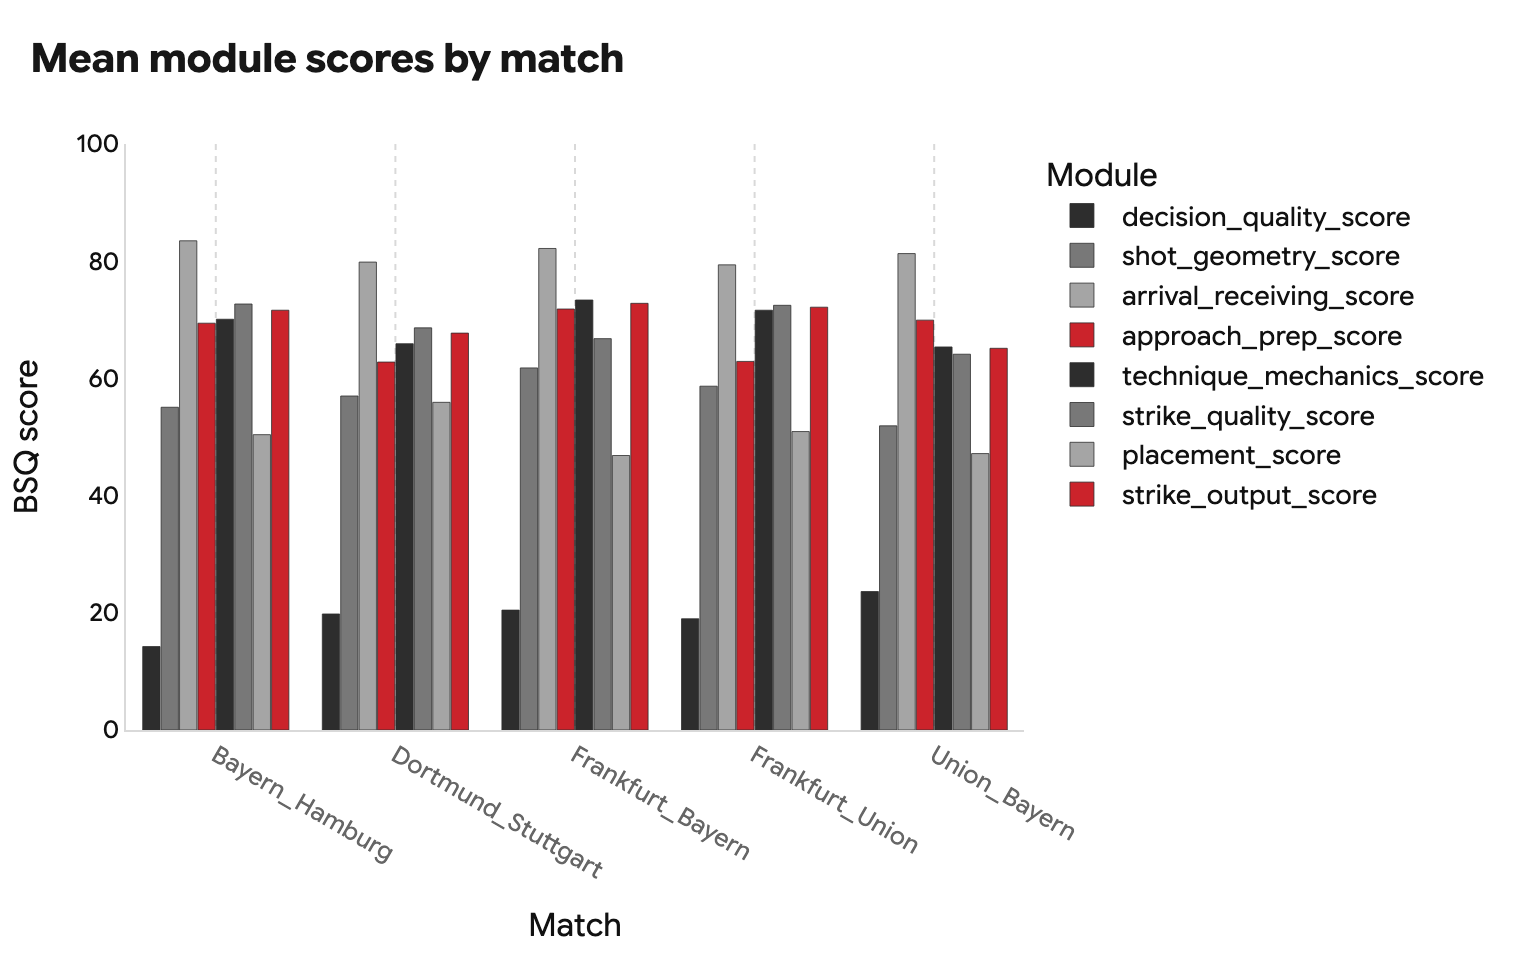

In [3]:
from aws_football.bsq_reports import plotly_league_modules_bar, display_plotly_figure, use_bsq_notebook_plotly
use_bsq_notebook_plotly()
melt = summary.melt(id_vars=['match_folder','shots'], value_vars=module_cols, var_name='module', value_name='score')
display_plotly_figure(plotly_league_modules_bar(melt))


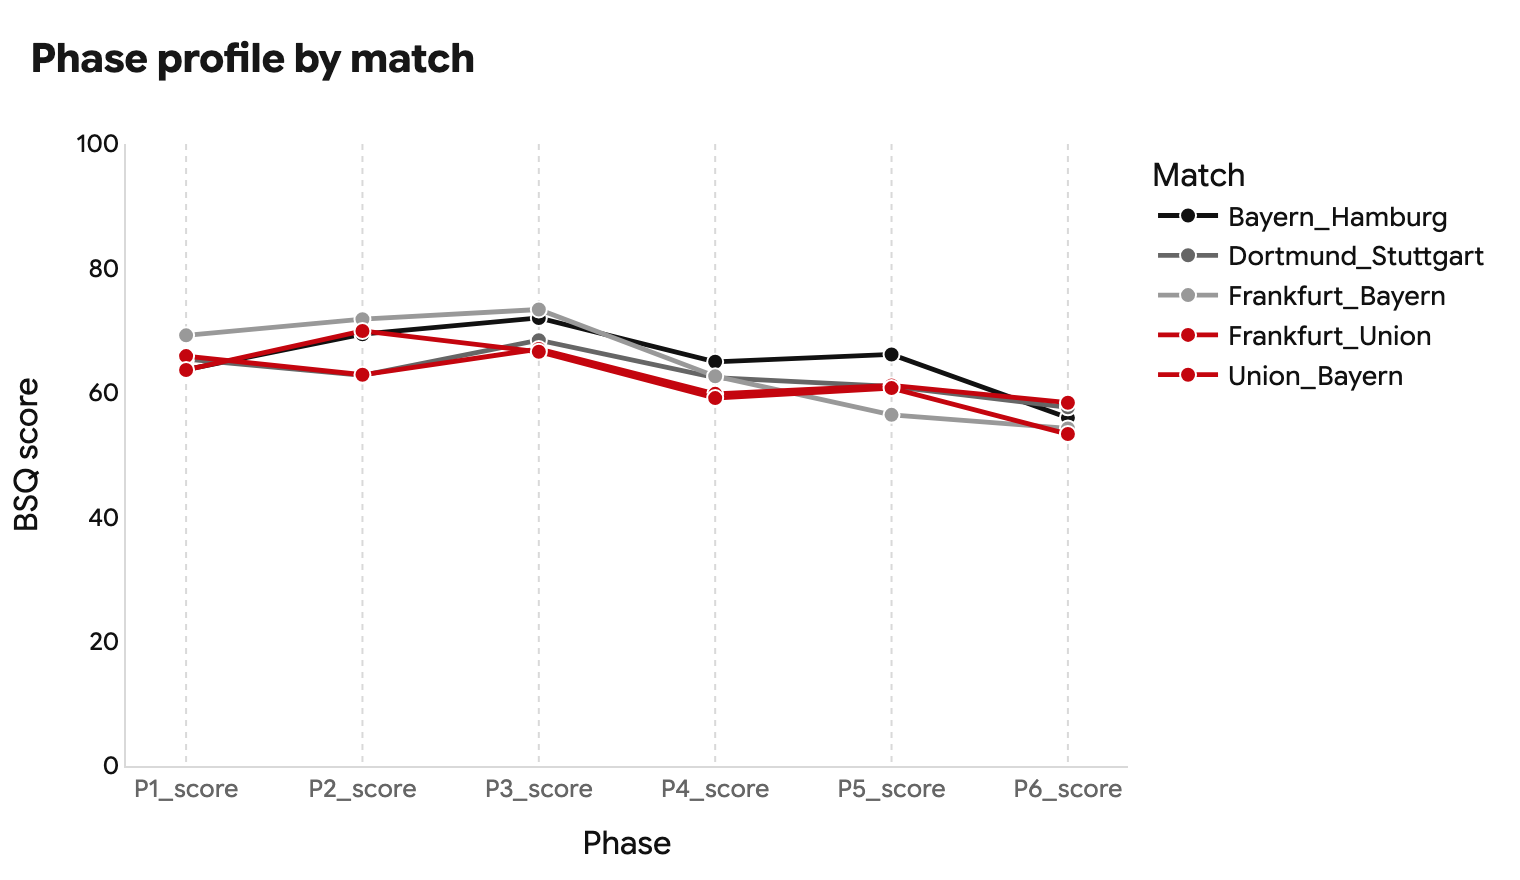

In [4]:
from aws_football.bsq_reports import plotly_phase_profile, display_plotly_figure
phase_cols = list(PHASE_COLUMNS.values())
pm = summary.melt(id_vars='match_folder', value_vars=phase_cols, var_name='phase', value_name='score')
display_plotly_figure(plotly_phase_profile(pm))
